SUMMARY INFO
numerical data: planned and measured value
class data: nomenclature
dimension data: category, subcategory, unit, indicator (many indicators by unit), location
id data: bond handle, project handle and name
dates: measurement period start and end

Missing data: see box below

Dimesion data: reviewed in excel to get a basic understanding of the data

Added cols: gbtp_alcns_df['Measurement period days']

Outliers: 

ALIGN WITH QUAL RESEARCH
 - CBI
 - META-ANALYSIS
 -     diff between planned and measured value?
 -     categorise indicators and categories
 -     combine category with geography and maturity
 -     compare project location with issuer jurisdiction

MISSING DATA QUESTIONS
missing nomenclature and category
missing measured value and planned value - how many bonds have at least one and how many bonds have none
missing records are all the same Bond and could potentially fixed by hand - looks like data is available at the platform but need to dig in to see how to aggregate 

generally harder to work with: several fine grained dimensions, see also violin plots and comment on lmplot. explore what seaborn plots might be useful. for projects dataset as well

methodology code - many missing values - discard?


In [1]:
import pandas as pd
gbtp_msrmnts_data = pd.read_csv('measurements.csv')
gbtp_msrmnts_df = pd.DataFrame(gbtp_msrmnts_data)
gbtp_msrmnts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7818 entries, 0 to 7817
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Bond handle                      7818 non-null   str    
 1   Bond name                        7818 non-null   str    
 2   Project handle                   7818 non-null   str    
 3   Project name                     7818 non-null   str    
 4   Nomenclature                     7793 non-null   str    
 5   Category                         7793 non-null   str    
 6   Subcategory                      1634 non-null   str    
 7   Location                         6583 non-null   str    
 8   Indicator                        7818 non-null   str    
 9   Unit                             7818 non-null   str    
 10  Planned value                    3856 non-null   float64
 11  Measured value                   4397 non-null   float64
 12  Can be aggregated              

In [2]:
gbtp_msrmnts_df.describe()

,Planned value,Measured value
count,3.856000e+03,4.397000e+03
mean,1.321882e+05,3.810068e+06
std,1.086433e+06,1.296713e+08
min,1.800000e-01,0.000000e+00
25%,4.777000e+02,7.200000e+01
50%,2.600000e+03,6.110000e+03
75%,6.330000e+03,8.588500e+04
max,1.790598e+07,6.072987e+09


In [3]:
gbtp_msrmnts_df.head()

,Bond handle,Bond name,Project handle,Project name,Nomenclature,Category,Subcategory,Location,Indicator,Unit,Planned value,Measured value,Can be aggregated,Methodology code,Measurement period start (date),Measurement period end (date)
0,65809b95fbf34e898b30b546b2d2a6a8,AES Argentina Green Bond,0e73a87a92b343599c42b78f8e59a2d0,Vientos Neuquinos,ISO,Unspecified,NaN,Neuquen,tCO2e avoided,metric ton,67584.0,67804.0,Yes,NaN,2020-10-01 00:00:00,2020-12-31 00:00:00
1,65809b95fbf34e898b30b546b2d2a6a8,AES Argentina Green Bond,0e73a87a92b343599c42b78f8e59a2d0,Vientos Neuquinos,EU Taxonomy Green Bonds Standard,Unspecified,NaN,Neuquen,tCO2e avoided,metric ton,67584.0,67804.0,Yes,NaN,2020-10-01 00:00:00,2020-12-31 00:00:00
2,65809b95fbf34e898b30b546b2d2a6a8,AES Argentina Green Bond,0e73a87a92b343599c42b78f8e59a2d0,Vientos Neuquinos,ICMA Green Bonds Principles Project Categories,Generation,Appliances,Neuquen,tCO2e avoided,metric ton,67584.0,67804.0,Yes,NaN,2020-10-01 00:00:00,2020-12-31 00:00:00
3,65809b95fbf34e898b30b546b2d2a6a8,AES Argentina Green Bond,0e73a87a92b343599c42b78f8e59a2d0,Vientos Neuquinos,ICMA Green Bonds Principles Project Categories,Generation,Products,Neuquen,tCO2e avoided,metric ton,67584.0,67804.0,Yes,NaN,2020-10-01 00:00:00,2020-12-31 00:00:00
4,65809b95fbf34e898b30b546b2d2a6a8,AES Argentina Green Bond,0e73a87a92b343599c42b78f8e59a2d0,Vientos Neuquinos,Climate Bonds Initiative Project Classification,Wind,NaN,Neuquen,tCO2e avoided,metric ton,67584.0,67804.0,Yes,NaN,2020-10-01 00:00:00,2020-12-31 00:00:00


In [4]:
gbtp_msrmnts_df.isnull().sum()

Bond handle                           0
Bond name                             0
Project handle                        0
Project name                          0
Nomenclature                         25
Category                             25
Subcategory                        6184
Location                           1235
Indicator                             0
Unit                                  0
Planned value                      3962
Measured value                     3421
Can be aggregated                     0
Methodology code                   7588
Measurement period start (date)       0
Measurement period end (date)         0
dtype: int64

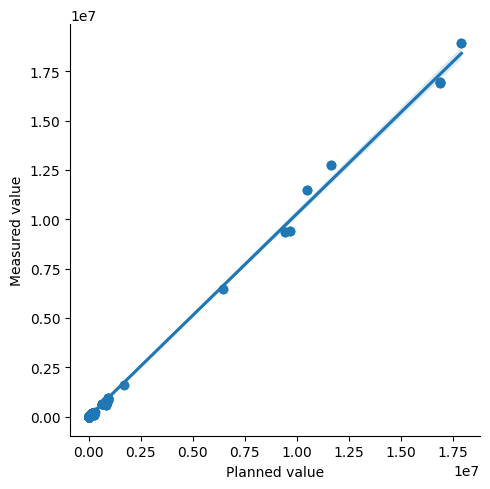

In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

import seaborn as sns

sns.lmplot(x='Planned value', y='Measured value', data=gbtp_msrmnts_df)

# what do missing values in these columns indicate
# useful and valid to create a column that takes measured value or if that's missing, planned value?

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, 'metric ton'),
  Text(1, 0, 'percent'),
  Text(2, 0, 'unit'),
  Text(3, 0, 'hectare'),
  Text(4, 0, 'megawatt'),
  Text(5, 0, 'cubic meters per second'),
  Text(6, 0, 'megawatt-hour'),
  Text(7, 0, 'cubic meter'),
  Text(8, 0, 'liter per second'),
  Text(9, 0, 'hour'),
  Text(10, 0, 'cubic meter per day'),
  Text(11, 0, 'liter'),
  Text(12, 0, 'square meter'),
  Text(13, 0, 'US Dollar'),
  Text(14, 0, 'ton per ton'),
  Text(15, 0, 'cubic meter per metric ton'),
  Text(16, 0, 'megawatt-hour per ton'),
  Text(17, 0, 'kilogram per cubic meter'),
  Text(18, 0, 'kilowatt-hour per cubic meter'),
  Text(19, 0, 'points'),
  Text(20, 0, 'day'),
  Text(21, 0, 'kilometer'),
  Text(22, 0, 'cubic meter per month'),
  Text(23, 0, 'decibel'),
  Text(24, 0, 'cubic meter per hour'),
  Text(25, 0, 'milligrams p

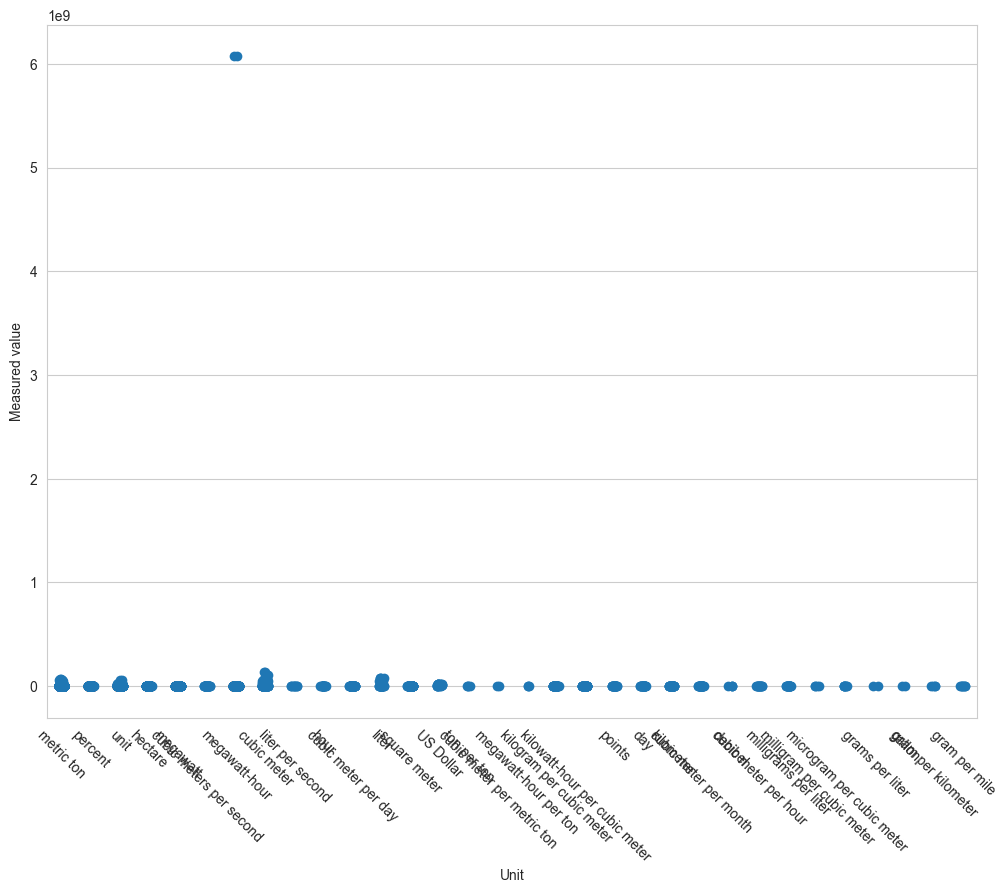

In [24]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.stripplot(x='Unit', y='Measured value', data= gbtp_msrmnts_df, size=7)
plt.xticks(rotation=-45)

([0, 1, 2, 3],
 [Text(0, 0, 'ISO'),
  Text(1, 0, 'EU Taxonomy Green Bonds Standard'),
  Text(2, 0, 'ICMA Green Bonds Principles Project Categories'),
  Text(3, 0, 'Climate Bonds Initiative Project Classification')])

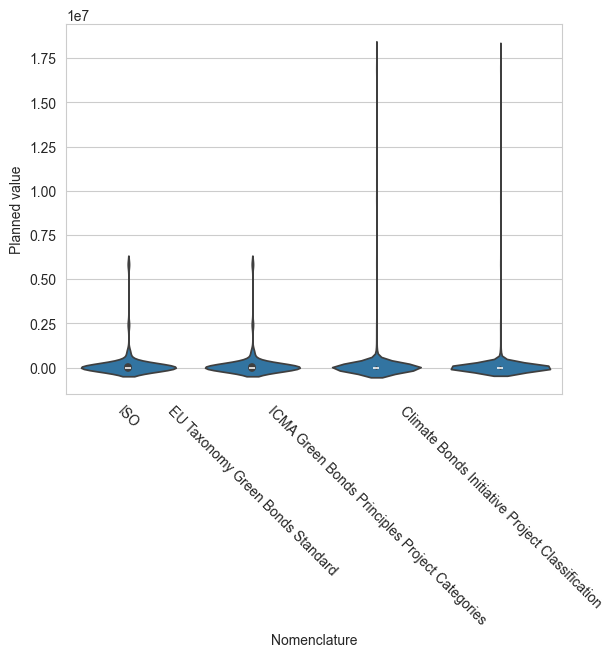

In [6]:
sns.set_style('whitegrid')

sns.violinplot(x='Nomenclature', y='Planned value', data=gbtp_msrmnts_df)
plt.xticks(rotation=-45)

([0, 1, 2, 3],
 [Text(0, 0, 'ISO'),
  Text(1, 0, 'EU Taxonomy Green Bonds Standard'),
  Text(2, 0, 'ICMA Green Bonds Principles Project Categories'),
  Text(3, 0, 'Climate Bonds Initiative Project Classification')])

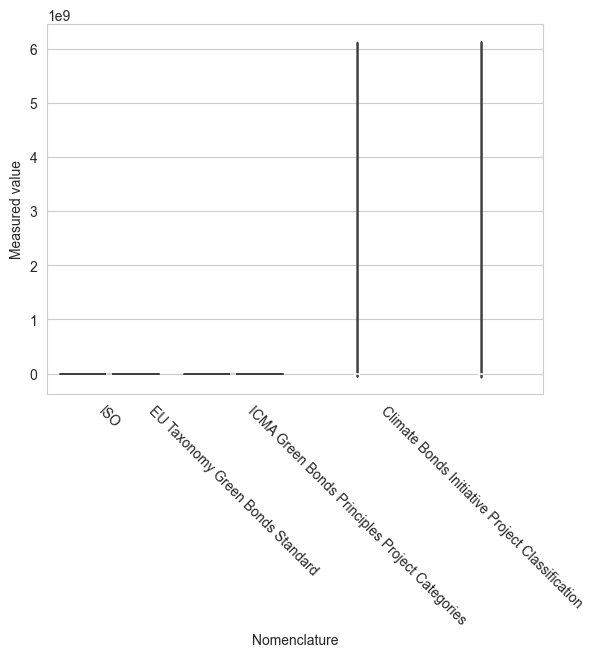

In [7]:
sns.set_style('whitegrid')

sns.violinplot(x='Nomenclature', y='Measured value', data=gbtp_msrmnts_df)
plt.xticks(rotation=-45)

In [17]:
sort_by_category = gbtp_msrmnts_df.groupby('Category').count().filter(['Bond handle'])
sort_by_category.sort_values('Bond handle', ascending=False)



,Bond handle
Category,
Generation,1634
Residential,1124
Unspecified,1080
Commercial,1047
Transmission,515
Solar,460
Wind,262
Treatment,252
Wastewater treatment,205


In [19]:
sort_by_location = gbtp_msrmnts_df.groupby('Location').count().filter(['Bond handle'])
sort_by_location.sort_values('Bond handle', ascending=False)

# also work out sort

,Bond handle
Location,
Bogota,1512
State of Minas Gerais,588
Cartagena,340
Pereira,224
SP,216
...,...
Tocantins,2
Valle del Cauca,2
Limeira-SP,2


In [20]:
sort_by_indicator = gbtp_msrmnts_df.groupby('Indicator').count().filter(['Bond handle'])
sort_by_indicator.sort_values('Bond handle', ascending=False)

,Bond handle
Indicator,
tCO2e avoided,1417
MWh renewable energy generation,1188
% energy saving,877
tCO2e reduced,652
% water saving,548
...,...
% critical suppliers evaluated,2
m³/t water recirculated/reused/replenish intensity,2
t GHG Balance,2


In [25]:
sort_by_unit = gbtp_msrmnts_df.groupby('Unit').count().filter(['Bond handle'])
sort_by_unit.sort_values('Bond handle', ascending=False)

,Bond handle
Unit,
metric ton,2316
percent,1945
megawatt-hour,1683
unit,632
megawatt,286
square meter,184
hectare,170
cubic meter,149
kilowatt-hour per cubic meter,48


learn about group by: split-apply-combine in Pandas

In [36]:
gbtp_msrmnts_df.groupby(['Indicator', 'Unit'])['Measured value'].sum()


Indicator                                        Unit                     
# NGV vehicles deployed                          unit                            2822.0
# Noise complaints                               unit                               0.0
# Odor complaints                                unit                               0.0
# audits                                         unit                             122.0
# births of fauna recognized by IUCN reproduced  unit                              58.0
                                                                                ...    
tCO2e reduced scope 2                            metric ton                       228.2
tCO2e reduced scope 3                            metric ton                      2585.5
tCO2e sequestered                                metric ton                   9910518.0
µg/m³ PM 10 level                                microgram per cubic meter         87.8
µg/m³ PM 2.5 level                           

moved over to excel

In [37]:
gbtp_msrmnts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7818 entries, 0 to 7817
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Bond handle                      7818 non-null   str    
 1   Bond name                        7818 non-null   str    
 2   Project handle                   7818 non-null   str    
 3   Project name                     7818 non-null   str    
 4   Nomenclature                     7793 non-null   str    
 5   Category                         7793 non-null   str    
 6   Subcategory                      1634 non-null   str    
 7   Location                         6583 non-null   str    
 8   Indicator                        7818 non-null   str    
 9   Unit                             7818 non-null   str    
 10  Planned value                    3856 non-null   float64
 11  Measured value                   4397 non-null   float64
 12  Can be aggregated              

In [38]:
gbtp_msrmnts_df['Measurement period start (date)'] = pd.to_datetime(gbtp_msrmnts_df['Measurement period start (date)'])
gbtp_msrmnts_df['Measurement period end (date)'] = pd.to_datetime(gbtp_msrmnts_df['Measurement period end (date)'])
gbtp_msrmnts_df['MP start date (epoch)'] = (gbtp_msrmnts_df['Measurement period start (date)'] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1s')
gbtp_msrmnts_df['MP end date (epoch)'] = (gbtp_msrmnts_df['Measurement period end (date)'] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1s')
seconds_in_day = 24*60*60
gbtp_msrmnts_df['Measurement period (days)'] = (gbtp_msrmnts_df['MP end date (epoch)'] - gbtp_msrmnts_df['MP start date (epoch)']) // seconds_in_day
gbtp_msrmnts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7818 entries, 0 to 7817
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Bond handle                      7818 non-null   str           
 1   Bond name                        7818 non-null   str           
 2   Project handle                   7818 non-null   str           
 3   Project name                     7818 non-null   str           
 4   Nomenclature                     7793 non-null   str           
 5   Category                         7793 non-null   str           
 6   Subcategory                      1634 non-null   str           
 7   Location                         6583 non-null   str           
 8   Indicator                        7818 non-null   str           
 9   Unit                             7818 non-null   str           
 10  Planned value                    3856 non-null   float64       
 11  Me

In [39]:
gbtp_msrmnts_df.describe()

,Planned value,Measured value,Measurement period start (date),Measurement period end (date),MP start date (epoch),MP end date (epoch),Measurement period (days)
count,3.856000e+03,4.397000e+03,7818,7818,7.818000e+03,7.818000e+03,7818.000000
mean,1.321882e+05,3.810068e+06,2021-01-22 14:05:37.068304,2022-01-23 16:48:59.677667,1.611324e+09,1.642957e+09,366.113456
min,1.800000e-01,0.000000e+00,2010-12-01 00:00:00,2015-12-01 00:00:00,1.291162e+09,1.448928e+09,0.000000
25%,4.777000e+02,7.200000e+01,2019-01-01 00:00:00,2019-12-01 00:00:00,1.546301e+09,1.575158e+09,335.000000
50%,2.600000e+03,6.110000e+03,2020-07-01 00:00:00,2021-06-30 00:00:00,1.593562e+09,1.625011e+09,364.000000
75%,6.330000e+03,8.588500e+04,2022-12-16 00:00:00,2023-12-01 00:00:00,1.671149e+09,1.701389e+09,365.000000
max,1.790598e+07,6.072987e+09,2036-01-01 00:00:00,2040-08-13 00:00:00,2.082758e+09,2.228429e+09,7305.000000
std,1.086433e+06,1.296713e+08,NaN,NaN,1.061128e+08,1.043705e+08,214.742373
